# Air Pollution Forecasting: PM2.5 Prediction with LSTM and Transformer

## Overview
This notebook forecasts hourly PM2.5 air pollution levels for Beijing using two deep learning architectures: a stacked **LSTM** and a **Transformer encoder**. Both models are trained on a multivariate time-series dataset and evaluated against the same held-out test set, allowing a direct performance comparison.

## Goals
- Explore and understand the structure of the pollution dataset
- Preprocess the data: encoding, normalization, and sliding-window sequence creation
- Train and tune an LSTM and a Transformer for single-step ahead PM2.5 forecasting
- Evaluate both models using MAE, RMSE, MAPE, and R²
- Compare model performance and discuss trade-offs

## Dataset
Hourly measurements from the US Embassy in Beijing (2010–2014), including PM2.5 concentration alongside meteorological variables: dew point, temperature, pressure, wind direction, wind speed, snowfall, and rainfall.

## Notebook Structure
1. **Setup:** Imports and global configuration
2. **Exploratory Data Analysis:** Distributions, correlations, and trend visualization of raw data
3. **Data Preprocessing:** Encoding, train/val/test split, scaling, and sequence creation
4. **LSTM:** Model definition, training, and evaluation
5. **Transformer:** Model definition, training, and evaluation
6. **Model Comparison**: Side-by-side metrics and loss curves
7. **Discussion:** Findings and conclusions

## 1. Setup

Define imports, path configuration, and the global `CONFIG` dictionary that controls all hyperparameters (sequence length, batch size, model dimensions, learning rate, and training budget). Changing a value here propagates through the entire notebook.

All core logic lives in `src/`: preprocessing pipelines (`src/preprocessing.py`), PyTorch datasets (`src/dataset.py`), model definitions (`src/models/`), and the training loop (`src/trainer.py`). This notebook imports from those modules and focuses on orchestration, visualization, and analysis rather than implementation.

In [1]:
import sys
sys.path.insert(0, ".")

import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from src.preprocessing import load_and_encode, split_data, fit_scaler, make_sequences, inverse_scale_pollution
from src.dataset import PollutionDataset
from src.models.lstm_model import LSTMForecaster
from src.models.transformer_model import TransformerForecaster
from src.trainer import run_training, predict, compute_metrics

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


In [2]:
CONFIG = {
    # Data
    "seq_len": 24,
    "batch_size": 64,
    "train_frac": 0.70,
    "val_frac": 0.15,
    # Training
    "lr": 1e-3,
    "n_epochs": 50,
    "patience": 10,
    # LSTM
    "lstm_hidden": 64,
    "lstm_layers": 2,
    "lstm_dropout": 0.2,
    # Transformer
    "d_model": 64,
    "nhead": 4,
    "num_encoder_layers": 2,
    "dim_feedforward": 128,
    "transformer_dropout": 0.1,
}

## 2. Exploratory Data Analysis

Overview of the raw dataset before any transformation: shape, dtypes, missing values, the PM2.5 time series, feature correlations, and a rolling-mean trend to surface seasonal patterns.

In [3]:
raw = pd.read_csv('data/LSTM-Multivariate_pollution.csv', parse_dates=['date'], index_col='date')
print(raw.shape)
raw.describe()

(43800, 8)


,pollution,dew,temp,press,wnd_spd,snow,rain
count,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000
mean,94.013516,1.828516,12.459041,1016.447306,23.894307,0.052763,0.195023
std,92.252276,14.429326,12.193384,10.271411,50.022729,0.760582,1.416247
min,0.000000,-40.000000,-19.000000,991.000000,0.450000,0.000000,0.000000
25%,24.000000,-10.000000,2.000000,1008.000000,1.790000,0.000000,0.000000
50%,68.000000,2.000000,14.000000,1016.000000,5.370000,0.000000,0.000000
75%,132.250000,15.000000,23.000000,1025.000000,21.910000,0.000000,0.000000
max,994.000000,28.000000,42.000000,1046.000000,585.600000,27.000000,36.000000


In [4]:
raw.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 43800 entries, 2010-01-02 00:00:00 to 2014-12-31 23:00:00
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pollution  43800 non-null  float64
 1   dew        43800 non-null  int64  
 2   temp       43800 non-null  float64
 3   press      43800 non-null  float64
 4   wnd_dir    43800 non-null  str    
 5   wnd_spd    43800 non-null  float64
 6   snow       43800 non-null  int64  
 7   rain       43800 non-null  int64  
dtypes: float64(4), int64(3), str(1)
memory usage: 3.0 MB


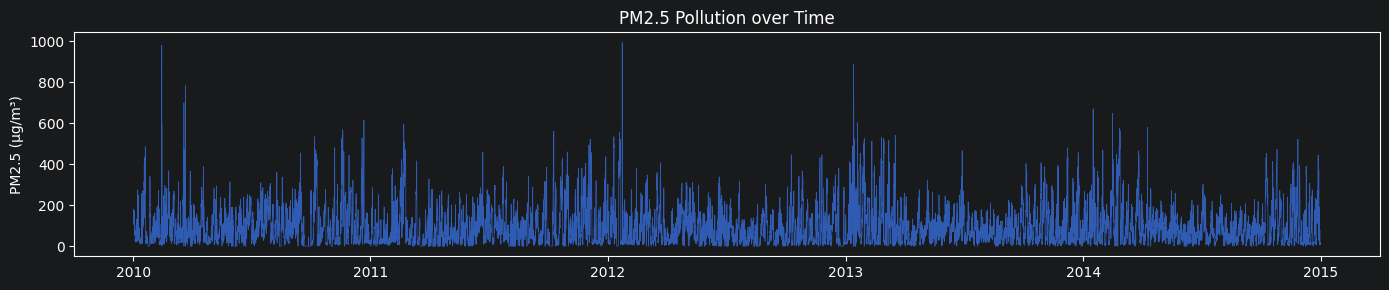

In [8]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(raw['pollution'], linewidth=0.5, alpha=0.8)
ax.set(title='PM2.5 Pollution over Time', ylabel='PM2.5 (μg/m³)')
plt.tight_layout()
plt.show()

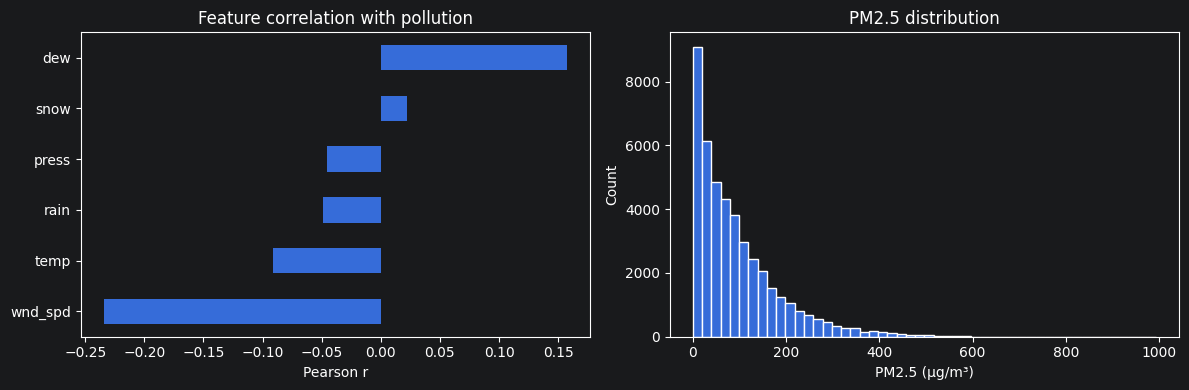

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

numeric = raw.drop(columns=['wnd_dir'])
corr = numeric.corr()[['pollution']].drop('pollution').sort_values('pollution')
corr.plot(kind='barh', ax=axes[0], legend=False)
axes[0].set(title='Feature correlation with pollution', xlabel='Pearson r')

axes[1].hist(raw['pollution'], bins=50, edgecolor='white')
axes[1].set(title='PM2.5 distribution', xlabel='PM2.5 (μg/m³)', ylabel='Count')

plt.tight_layout()
plt.show()

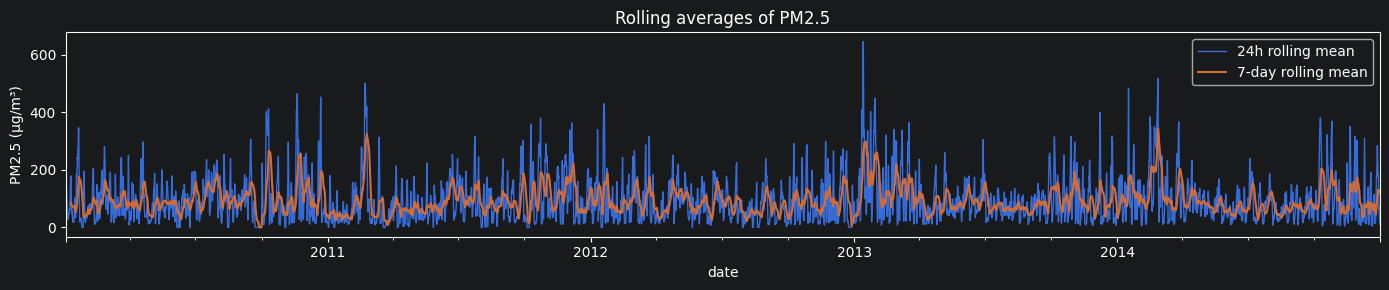

In [5]:
fig, ax = plt.subplots(figsize=(14, 3))
raw['pollution'].rolling(24).mean().plot(ax=ax, label='24h rolling mean', linewidth=1)
raw['pollution'].rolling(24*7).mean().plot(ax=ax, label='7-day rolling mean', linewidth=1.5)
ax.set(title='Rolling averages of PM2.5', ylabel='PM2.5 (μg/m³)')
ax.legend()
plt.tight_layout()
plt.show()

EDA findings

## 3. Preprocessing

Four steps to go from raw CSV to model-ready tensors:
1. One-hot encode the categorical wind direction feature
2. Chronologically split into train (70%), validation (15%), and test (15%) sets
3. Fit a MinMaxScaler on training data only and transform all splits
4. Build sliding-window sequences of length `seq_len` for supervised learning

In [11]:
df = load_and_encode('data/LSTM-Multivariate_pollution.csv')
print('Columns:', df.columns.tolist())
print('Shape:', df.shape)

Columns: ['pollution', 'dew', 'temp', 'press', 'wnd_spd', 'snow', 'rain', 'wnd_dir_NE', 'wnd_dir_NW', 'wnd_dir_SE', 'wnd_dir_cv']
Shape: (43800, 11)


In [12]:
train_df, val_df, test_df = split_data(df, CONFIG['train_frac'], CONFIG['val_frac'])
print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Train: 30,659 | Val: 6,571 | Test: 6,570


In [13]:
scaler, train_arr, val_arr, test_arr = fit_scaler(train_df, val_df, test_df)

X_train, y_train = make_sequences(train_arr, CONFIG['seq_len'])
X_val,   y_val   = make_sequences(val_arr,   CONFIG['seq_len'])
X_test,  y_test  = make_sequences(test_arr,  CONFIG['seq_len'])

print(f'X_train: {X_train.shape} | y_train: {y_train.shape}')
print(f'X_val:   {X_val.shape}   | y_val:   {y_val.shape}')
print(f'X_test:  {X_test.shape}  | y_test:  {y_test.shape}')

X_train: (30635, 24, 11) | y_train: (30635,)
X_val:   (6547, 24, 11)   | y_val:   (6547,)
X_test:  (6546, 24, 11)  | y_test:  (6546,)


In [14]:
train_loader = DataLoader(PollutionDataset(X_train, y_train), batch_size=CONFIG['batch_size'], shuffle=True)
val_loader   = DataLoader(PollutionDataset(X_val,   y_val),   batch_size=CONFIG['batch_size'], shuffle=False)
test_loader  = DataLoader(PollutionDataset(X_test,  y_test),  batch_size=CONFIG['batch_size'], shuffle=False)

## 4. LSTM

A stacked two-layer LSTM with dropout, trained end-to-end to predict the next PM2.5 value from the previous `seq_len` hourly observations.

### 4.1 Training

The model is trained with Adam and MSE loss. A `ReduceLROnPlateau` scheduler halves the learning rate after 5 epochs without validation improvement, and early stopping (patience 10) prevents overfitting.

In [15]:
input_size = X_train.shape[2]

lstm_model = LSTMForecaster(
    input_size=input_size,
    hidden_size=CONFIG["lstm_hidden"],
    num_layers=CONFIG["lstm_layers"],
    dropout=CONFIG["lstm_dropout"],
).to(DEVICE)

total_params = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(lstm_model)
print(f"\nTrainable parameters: {total_params:,}")

LSTMForecaster(
  (lstm): LSTM(11, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters: 53,057


In [28]:
criterion = nn.MSELoss()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=CONFIG["lr"])
lstm_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(lstm_optimizer, patience=5, factor=0.5)

lstm_train_losses, lstm_val_losses, lstm_best_weights = run_training(
    lstm_model, train_loader, val_loader,
    lstm_optimizer, criterion, lstm_scheduler,
    n_epochs=CONFIG["n_epochs"],
    device=DEVICE,
    patience=CONFIG["patience"],
)

torch.save(lstm_best_weights, "model_weights/lstm_best.pt")
print("Best weights saved to model_weights/lstm_best.pt")

Epoch   1 | train loss: 0.000676 | val loss: 0.000526
Epoch   5 | train loss: 0.000661 | val loss: 0.000552
Epoch  10 | train loss: 0.000629 | val loss: 0.000567
Early stopping at epoch 11 (no improvement for 10 epochs)
Best weights saved to lstm_best.pt


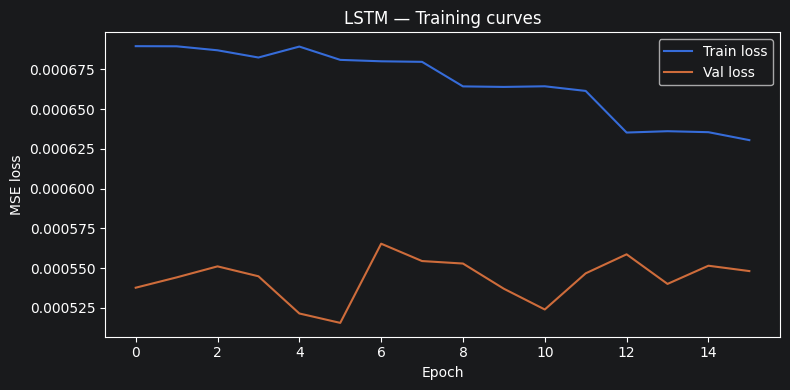

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lstm_train_losses, label="Train loss")
ax.plot(lstm_val_losses,   label="Val loss")
ax.set(title="LSTM — Training curves", xlabel="Epoch", ylabel="MSE loss")
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Evaluation

The best checkpoint (lowest validation loss) is loaded and run on the held-out test set. Predictions are inverse-scaled back to PM2.5 units before computing metrics.

In [16]:
lstm_model.load_state_dict(torch.load("model_weights/lstm_best.pt", map_location=DEVICE))

lstm_preds_scaled = predict(lstm_model, test_loader, DEVICE)
lstm_preds = inverse_scale_pollution(scaler, lstm_preds_scaled)
y_test_original = inverse_scale_pollution(scaler, y_test)

lstm_metrics = compute_metrics(y_test_original, lstm_preds)
print("LSTM Test Metrics:")
for k, v in lstm_metrics.items():
    print(f"  {k}: {v:.4f}")

LSTM Test Metrics:
  MAE: 11.2861
  RMSE: 21.6253
  MAPE: 23.2638
  R2: 0.9248


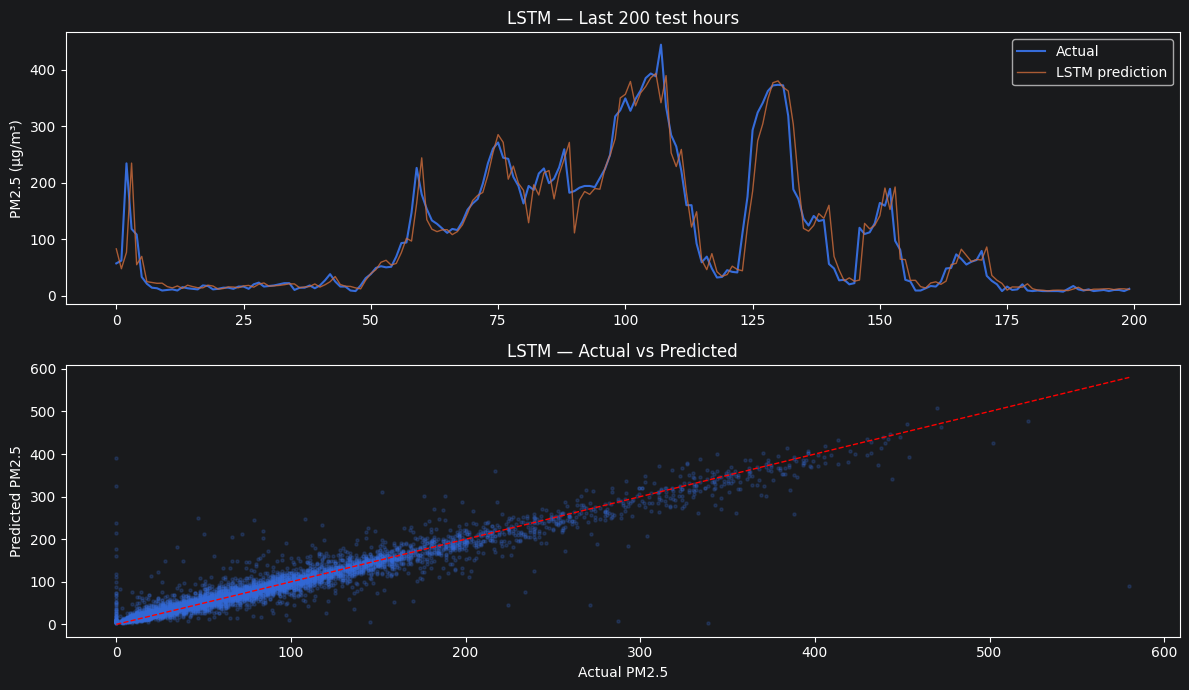

In [17]:
n_show = 200
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(y_test_original[-n_show:], label='Actual', linewidth=1.5)
axes[0].plot(lstm_preds[-n_show:],      label='LSTM prediction', linewidth=1, alpha=0.8)
axes[0].set(title=f'LSTM — Last {n_show} test hours', ylabel='PM2.5 (μg/m³)')
axes[0].legend()

axes[1].scatter(y_test_original, lstm_preds, alpha=0.2, s=5)
lims = [min(y_test_original.min(), lstm_preds.min()),
        max(y_test_original.max(), lstm_preds.max())]
axes[1].plot(lims, lims, 'r--', linewidth=1)
axes[1].set(title='LSTM — Actual vs Predicted', xlabel='Actual PM2.5', ylabel='Predicted PM2.5')

plt.tight_layout()
plt.show()

## 5. Transformer

An encoder-only Transformer with sinusoidal positional encoding, trained on the same sequences and objective as the LSTM for a fair comparison.

### 5.1 Training

Same training setup as the LSTM: Adam optimizer, MSE loss, `ReduceLROnPlateau` scheduler, and early stopping.

In [18]:
transformer_model = TransformerForecaster(
    input_size=input_size,
    d_model=CONFIG["d_model"],
    nhead=CONFIG["nhead"],
    num_encoder_layers=CONFIG["num_encoder_layers"],
    dim_feedforward=CONFIG["dim_feedforward"],
    dropout=CONFIG["transformer_dropout"],
).to(DEVICE)

total_params = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)
print(transformer_model)
print(f"\nTrainable parameters: {total_params:,}")

TransformerForecaster(
  (input_proj): Linear(in_features=11, out_features=64, bias=True)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=128, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Trainable parameters: 67,777


In [20]:
criterion = nn.MSELoss()
transformer_optimizer = torch.optim.Adam(transformer_model.parameters(), lr=CONFIG["lr"])
transformer_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(transformer_optimizer, patience=5, factor=0.5)

tr_train_losses, tr_val_losses, tr_best_weights = run_training(
    transformer_model, train_loader, val_loader,
    transformer_optimizer, criterion, transformer_scheduler,
    n_epochs=CONFIG["n_epochs"],
    device=DEVICE,
    patience=CONFIG["patience"],
)

torch.save(tr_best_weights, "model_weights/transformer_best.pt")
print("Best weights saved to model_weights/transformer_best.pt")

Epoch   1 | train loss: 0.012433 | val loss: 0.000956
Epoch   5 | train loss: 0.001042 | val loss: 0.000799
Epoch  10 | train loss: 0.000932 | val loss: 0.000656
Epoch  15 | train loss: 0.000878 | val loss: 0.000718
Epoch  20 | train loss: 0.000837 | val loss: 0.000618
Early stopping at epoch 24 (no improvement for 10 epochs)
Best weights saved to transformer_best.pt


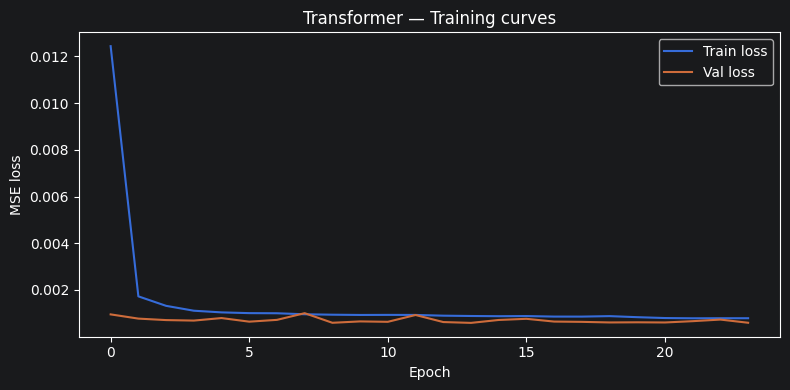

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tr_train_losses, label="Train loss")
ax.plot(tr_val_losses,   label="Val loss")
ax.set(title="Transformer — Training curves", xlabel="Epoch", ylabel="MSE loss")
ax.legend()
plt.tight_layout()
plt.show()

### 5.2 Evaluation

Best checkpoint loaded and evaluated on the test set under identical conditions as the LSTM.

In [22]:
transformer_model.load_state_dict(torch.load("model_weights/transformer_best.pt", map_location=DEVICE))

tr_preds_scaled = predict(transformer_model, test_loader, DEVICE)
tr_preds = inverse_scale_pollution(scaler, tr_preds_scaled)

tr_metrics = compute_metrics(y_test_original, tr_preds)
print("Transformer Test Metrics:")
for k, v in tr_metrics.items():
    print(f"  {k}: {v:.4f}")

Transformer Test Metrics:
  MAE: 11.9297
  RMSE: 22.0784
  MAPE: 28.6443
  R2: 0.9216


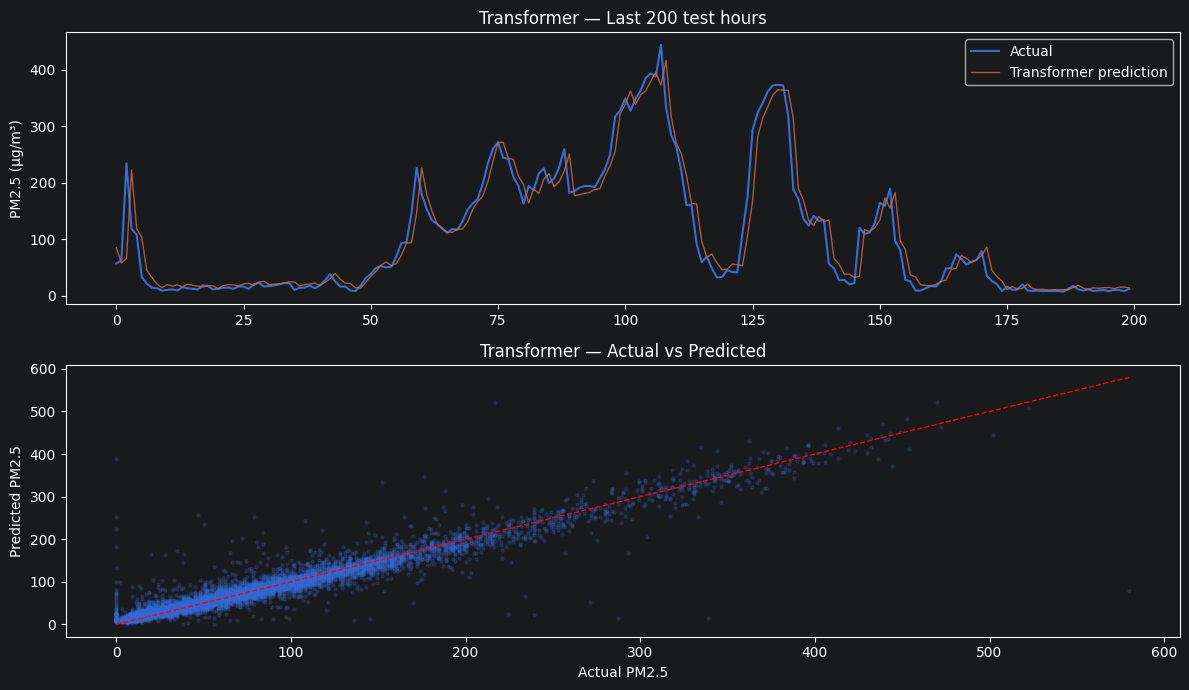

In [23]:
n_show = 200
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(y_test_original[-n_show:], label="Actual", linewidth=1.5)
axes[0].plot(tr_preds[-n_show:],        label="Transformer prediction", linewidth=1, alpha=0.8)
axes[0].set(title=f"Transformer — Last {n_show} test hours", ylabel="PM2.5 (μg/m³)")
axes[0].legend()

axes[1].scatter(y_test_original, tr_preds, alpha=0.2, s=5)
lims = [min(y_test_original.min(), tr_preds.min()),
        max(y_test_original.max(), tr_preds.max())]
axes[1].plot(lims, lims, "r--", linewidth=1)
axes[1].set(title="Transformer — Actual vs Predicted", xlabel="Actual PM2.5", ylabel="Predicted PM2.5")

plt.tight_layout()
plt.show()

## 6. Model Comparison

Side-by-side comparison of LSTM and Transformer across all four metrics, plus overlaid training curves to visualise convergence speed and stability.

In [24]:
comparison = pd.DataFrame(
    {"LSTM": lstm_metrics, "Transformer": tr_metrics}
).T.round(4)
comparison

,MAE,RMSE,MAPE,R2
LSTM,11.2861,21.6253,23.2638,0.9248
Transformer,11.9297,22.0784,28.6443,0.9216


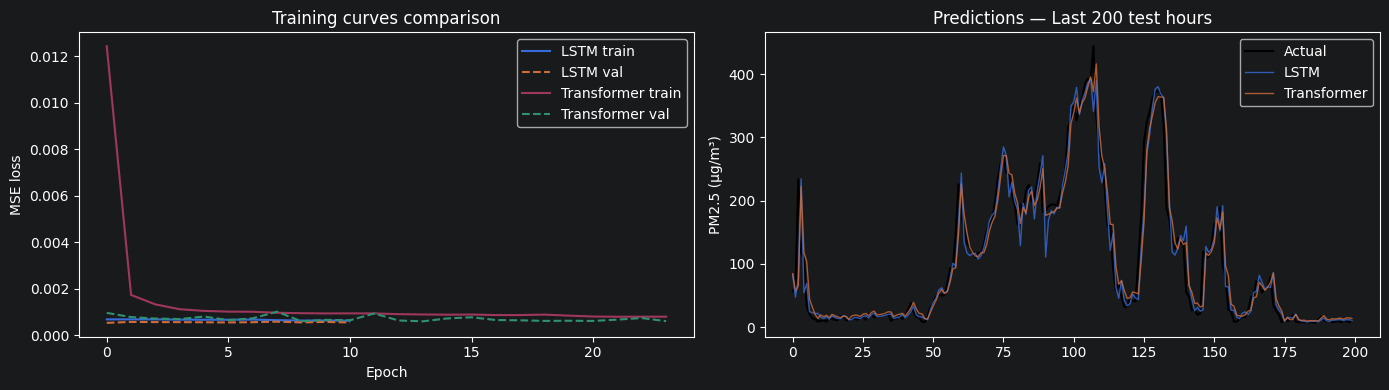

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(lstm_train_losses, label="LSTM train")
axes[0].plot(lstm_val_losses,   label="LSTM val",         linestyle="--")
axes[0].plot(tr_train_losses,   label="Transformer train")
axes[0].plot(tr_val_losses,     label="Transformer val",  linestyle="--")
axes[0].set(title="Training curves comparison", xlabel="Epoch", ylabel="MSE loss")
axes[0].legend()

n_show = 200
axes[1].plot(y_test_original[-n_show:], label="Actual",      linewidth=1.5, color="black")
axes[1].plot(lstm_preds[-n_show:],      label="LSTM",        linewidth=1, alpha=0.8)
axes[1].plot(tr_preds[-n_show:],        label="Transformer", linewidth=1, alpha=0.8)
axes[1].set(title=f"Predictions — Last {n_show} test hours", ylabel="PM2.5 (μg/m³)")
axes[1].legend()

plt.tight_layout()
plt.show()

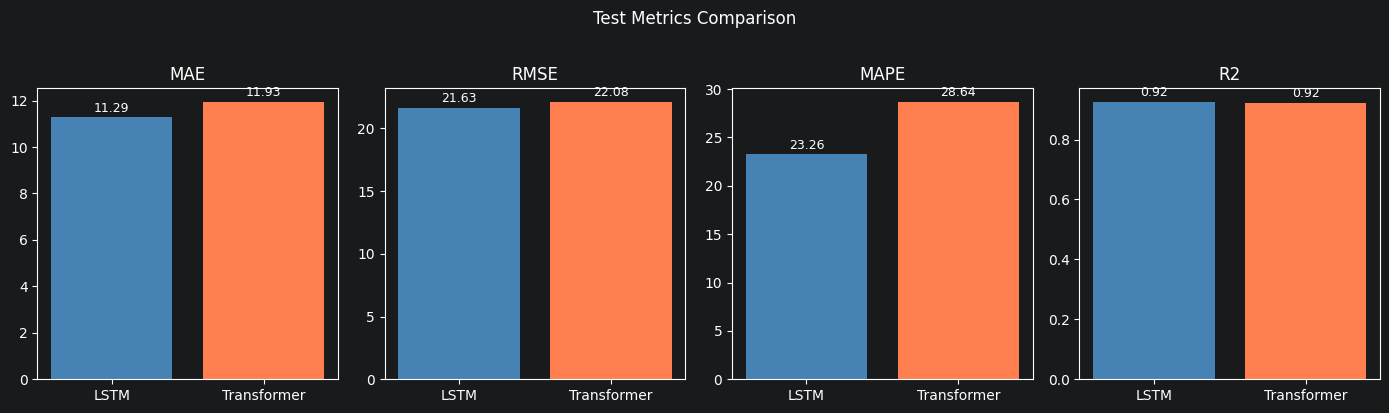

In [30]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
metrics_list = list(lstm_metrics.keys())

for ax, metric in zip(axes, metrics_list):
    values = [lstm_metrics[metric], tr_metrics[metric]]
    bars = ax.bar(["LSTM", "Transformer"], values, color=["steelblue", "coral"])
    ax.set_title(metric)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Test Metrics Comparison", y=1.02)
plt.tight_layout()
plt.show()

## 7. Discussion and Analysis